In [ ]:
import pandas as pd
import numpy as np
import pyreadr
import sys
import os
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from python.disco import DiSCo
from python.temp.data import get_contunious_data, get_discrete_data
from python.evaluation.visualization import (plot_fit_quantiles, plot_fit_cdf, plot_fit_copula, plot_fit_joint_contour,
plot_fit_scatter2d)

from python.tea import disco_tea

from python.evaluation.metrics import calculate_pretreatment_fit

In [2]:
data = pd.read_csv('../datasets/dube_small.csv')

# Univariat
### Wenige Controls

In [3]:
uni_low_contols =  get_contunious_data(1000,num_controls=4, dim=1)

In [4]:
# DiSCo
disco_uni = DiSCo(
    df=data,
    id_col='fips',
    time_col='year',
    y_col='adj0contpov',
    id_col_target=1,     
    t0=2011,             
    M=1000,              
    G=1000,             
    num_cores=1,        
    simplex=True,        
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=False
)
disco_uni = disco_uni.fit()

In [5]:
#mixture
mixture_uni = DiSCo(
    df=data,
    id_col='fips',
    time_col='year',
    y_col='adj0contpov',
    id_col_target=1,     # Spalte '0' als Treatment
    t0=2011,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=1000,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=True
)
mixture_uni = mixture_uni.fit()

c:\Dokumente\Studium\1. Master Thesis\DiSCos\python\solvers.py:282: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=10000, eps=1e-5)


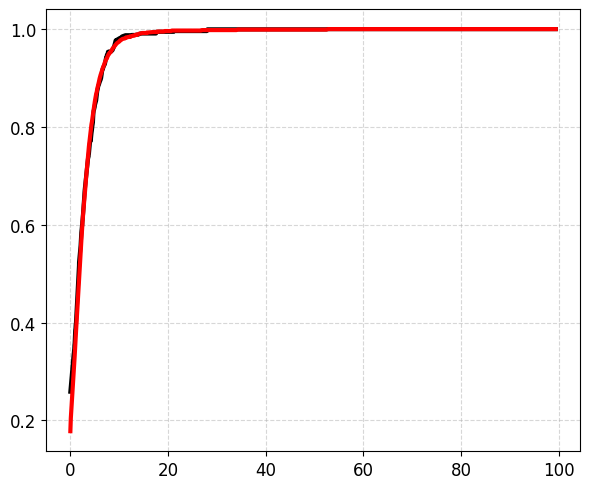

In [6]:
plot_fit_cdf(disco_uni)

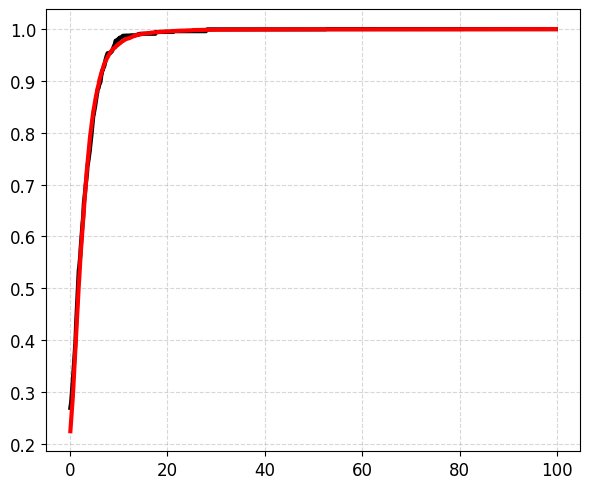

In [7]:
plot_fit_cdf(mixture_uni)

In [8]:
calculate_pretreatment_fit(disco_uni).metrics_per_period[2]

{'w1': 0.24076298442351002,
 'energy_dist': 0.08080005742508119,
 'ks_stat': [np.float64(0.036)],
 'mean_diff': [np.float64(0.05846734362350903)],
 'cov_error': 3.5913309378166822}

In [9]:
calculate_pretreatment_fit(mixture_uni).metrics_per_period[2]

{'w1': 0.1656645225503001,
 'energy_dist': 0.06736401054655669,
 'ks_stat': [np.float64(0.048)],
 'mean_diff': [np.float64(0.04160962815029956)],
 'cov_error': 0.46912390305160656}

# Multivariat
### Wenige Controls

In [10]:
# DiSCo
disco_multi = DiSCo(
    df=data,
    id_col='fips',
    time_col='year',
    y_col=['adj0contpov','age'],
    id_col_target=1,     
    t0=2011,             
    M=1000,              
    G=100,              
    num_cores=-1,        
    simplex=True,        
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=False
)
disco_multi = disco_multi.fit()

In [11]:
#mixture
mixture_multi = DiSCo(
    df=data,
    id_col='fips',
    time_col='year',
    y_col=['adj0contpov','age'],
    id_col_target=1,     # Spalte '0' als Treatment
    t0=2011,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=100,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=True
)
mixture_multi = mixture_multi.fit()

c:\Dokumente\Studium\1. Master Thesis\DiSCos\python\solvers.py:282: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=10000, eps=1e-5)


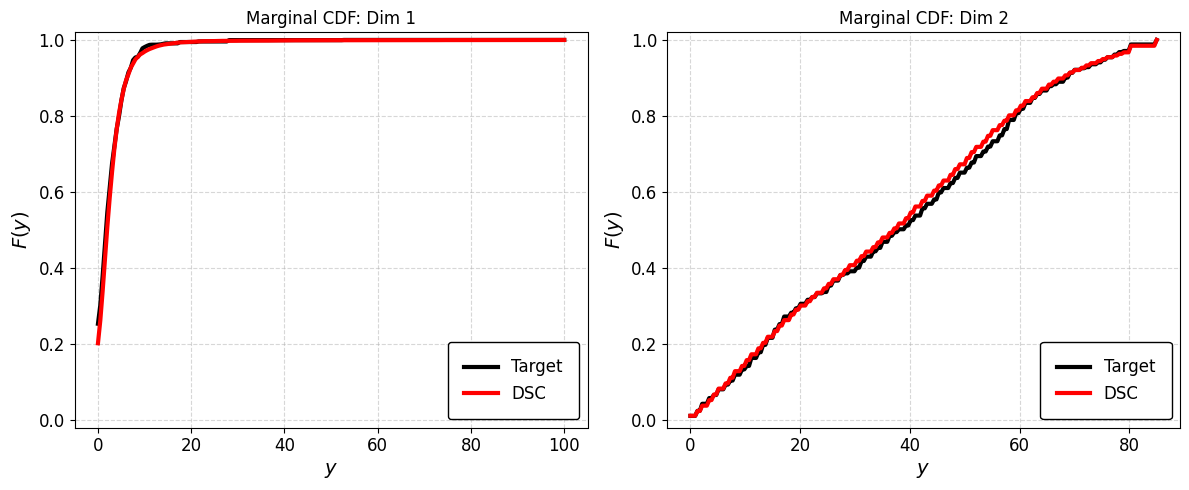

In [12]:
plot_fit_cdf(disco_multi)

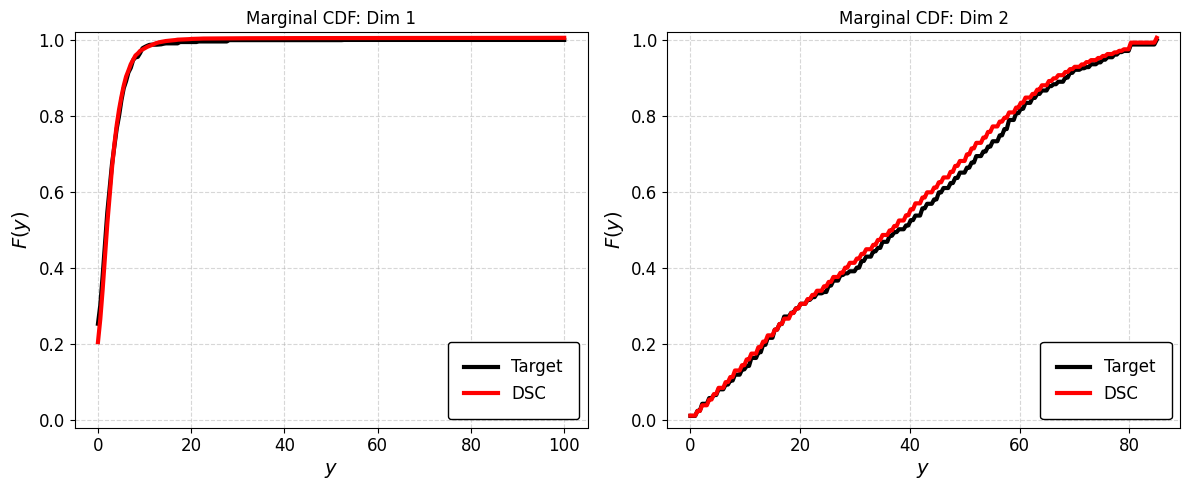

In [13]:
plot_fit_cdf(mixture_multi)

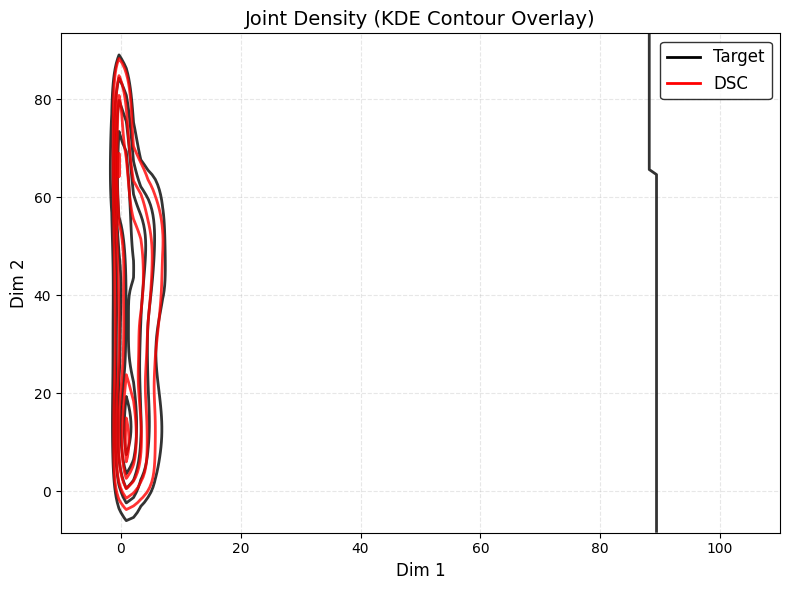

In [14]:
plot_fit_joint_contour(disco_multi)

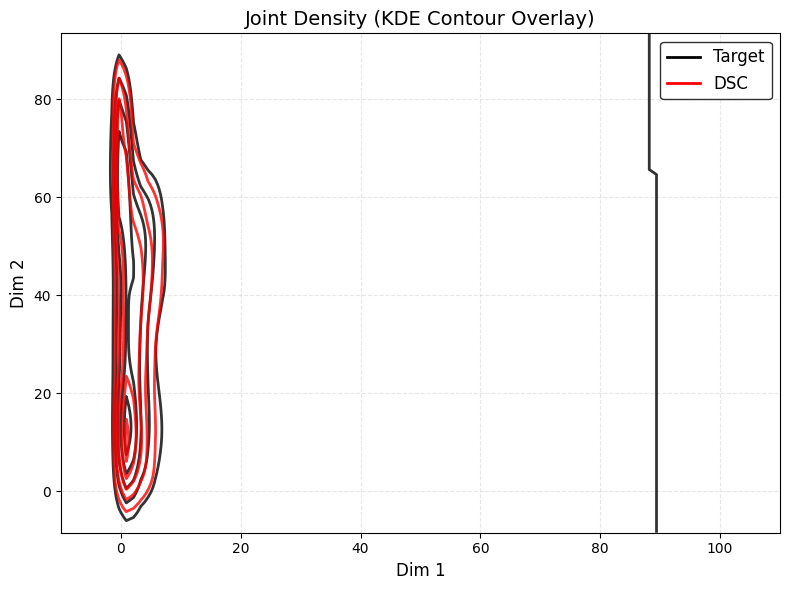

In [15]:
plot_fit_joint_contour(mixture_multi)

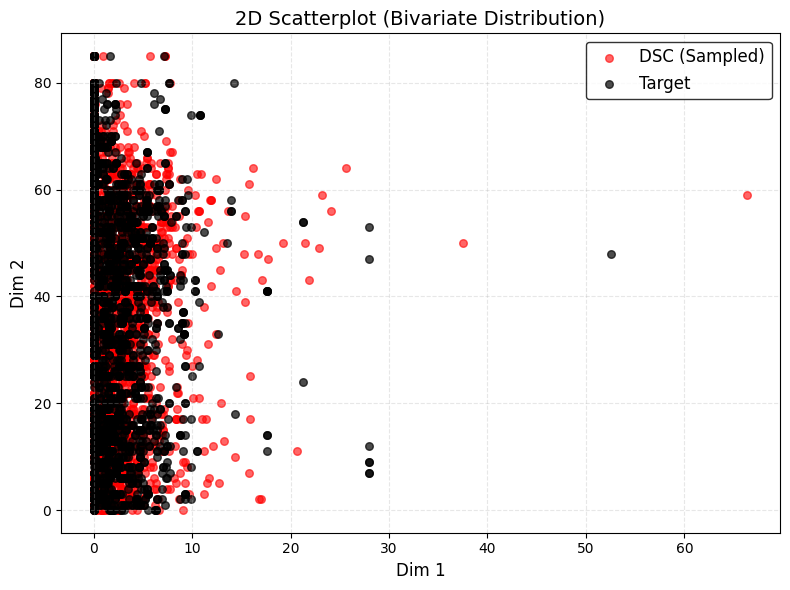

In [16]:
plot_fit_scatter2d(disco_multi)

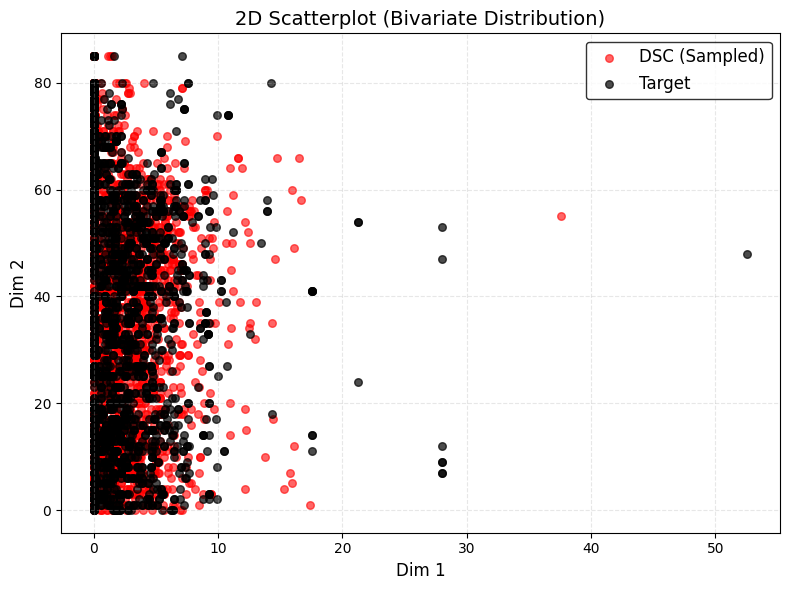

In [17]:
plot_fit_scatter2d(mixture_multi)

In [18]:
calculate_pretreatment_fit(disco_multi).energy_dist

27.149683352981075

In [19]:
calculate_pretreatment_fit(mixture_multi).energy_dist

26.060637181509986

In [20]:
fit_df = mixture_multi.params.df


Call:
DiSCoTEA

--- Treatment Effects ---
  Time  X_from  X_to  Quantile Delta  Std. Error  [95%   Conf. Band] Sig
 76600     0.0   1.0          0.0095         NaN    NaN          NaN    
 48928     0.0   1.0         -0.1171         NaN    NaN          NaN    
117125     0.0   1.0         -0.1036         NaN    NaN          NaN    
 62010     0.0   1.0          0.0016         NaN    NaN          NaN    
 58510     0.0   1.0         -0.0580         NaN    NaN          NaN    




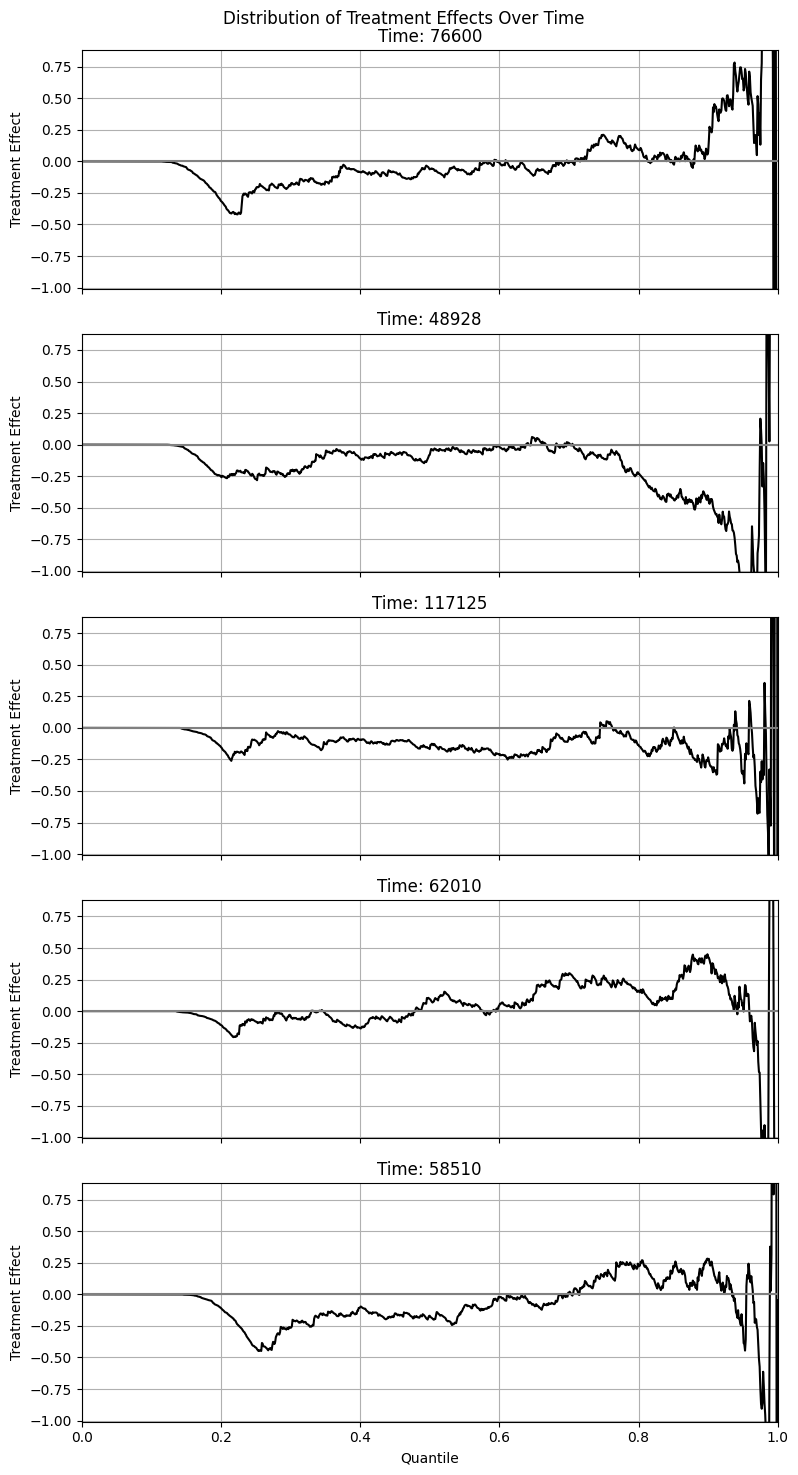

In [21]:
import python.tea as tea

tea.disco_tea(disco_uni, agg='marginals', graph=True, samples=[0.0])[0].summary()

In [27]:
import python.tea as tea

tea.disco_tea(disco_multi, agg='transport_map', graph=True, samples=[0.0,0.5]).treats[76600]

,Q1_Q1,Q1_Q2,Q2_Q1,Q2_Q2
Q1_Q1,24.2,0.00,1.00,0.00
Q1_Q2,0.4,24.25,0.00,0.20
Q2_Q1,0.3,0.00,24.05,0.50
Q2_Q2,0.0,0.95,0.80,23.35


# Data

In [ ]:
pd.read_csv

<function pandas.read_csv(filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]', *, sep: 'str | None | lib.NoDefault' = <no_default>, delimiter: 'str | None | lib.NoDefault' = None, header: "int | Sequence[int] | None | Literal['infer']" = 'infer', names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>, index_col: 'IndexLabel | Literal[False] | None' = None, usecols: 'UsecolsArgType' = None, dtype: 'DtypeArg | None' = None, engine: 'CSVEngine | None' = None, converters: 'Mapping[HashableT, Callable] | None' = None, true_values: 'list | None' = None, false_values: 'list | None' = None, skipinitialspace: 'bool' = False, skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None, skipfooter: 'int' = 0, nrows: 'int | None' = None, na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None, keep_default_na: 'bool' = True, na_filter: 'bool' = True, skip_blank_lines: 'bool' = True, parse_dates: 'bool | Sequence[